<a href="https://colab.research.google.com/github/Abhinavharle45-hub/CodeAlpha_ProjectName/blob/main/Task1_Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 · Iris Flower Classification

**Objective:** Train a machine learning classification model to identify the species of an iris flower (Setosa, Versicolor, or Virginica) from its physical measurements.

**Tech Stack:** Python, scikit-learn, pandas, matplotlib/seaborn, Jupyter Notebook

## 1. Load the Dataset

The Iris dataset is built into scikit-learn, so no external download is needed.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Convert to DataFrame for easier exploration
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Exploratory Data Analysis (EDA)

Check the shape, data types, missing values, and descriptive statistics of the dataset.

In [ ]:
# Shape of the dataset
print("Shape:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Missing value check
print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (150, 6)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [ ]:
# Descriptive statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
# Class balance
df['species_name'].value_counts()

,count
species_name,
setosa,50
versicolor,50
virginica,50


## 3. Visualisations

Pairplot to see feature distributions by species, and box plots for each feature.

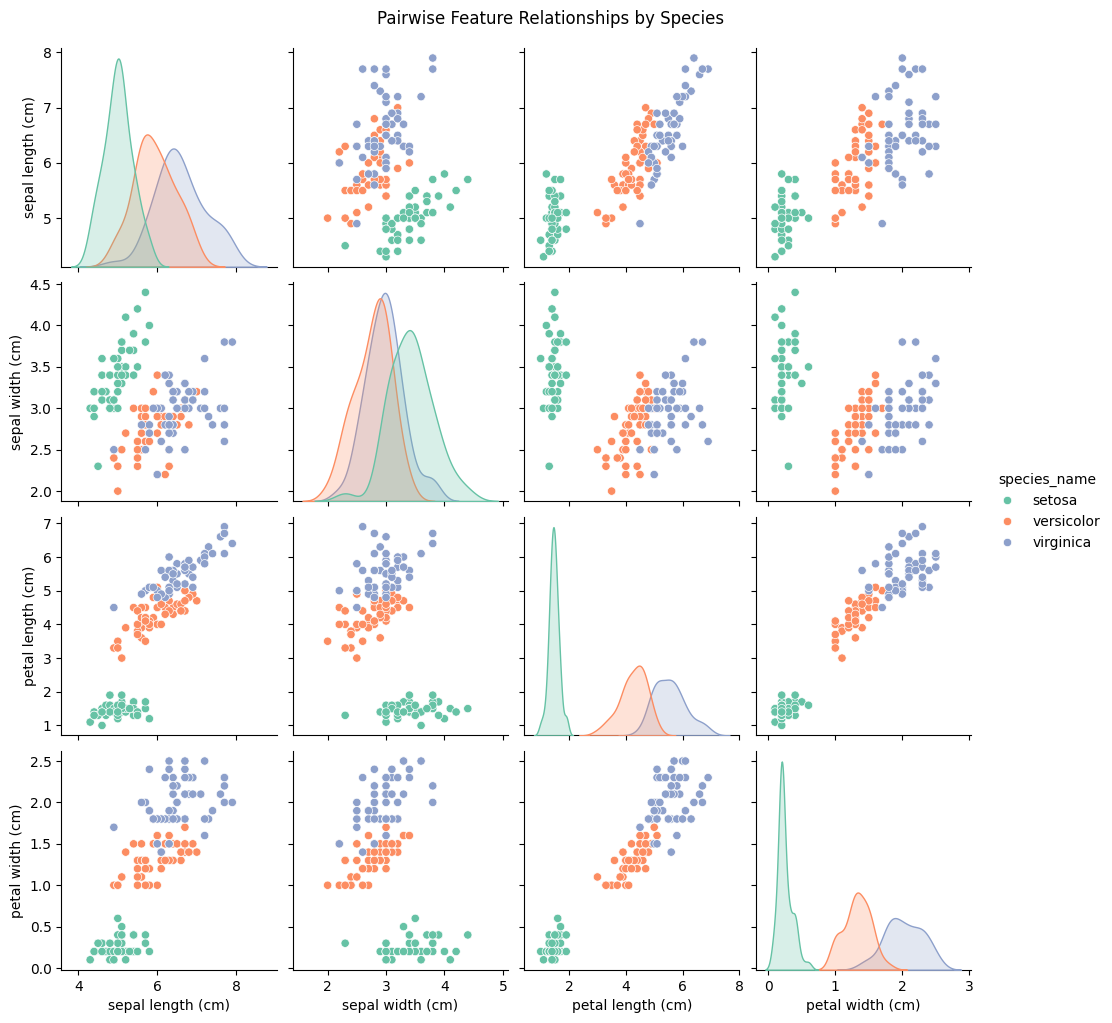

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='species_name', vars=iris.feature_names, palette='Set2')
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()

/tmp/ipykernel_1410/2727500204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=ax, palette='Set2')
/tmp/ipykernel_1410/2727500204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=ax, palette='Set2')
/tmp/ipykernel_1410/2727500204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=ax, palette='Set2')
/tmp/ipykernel_1410/2727500204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

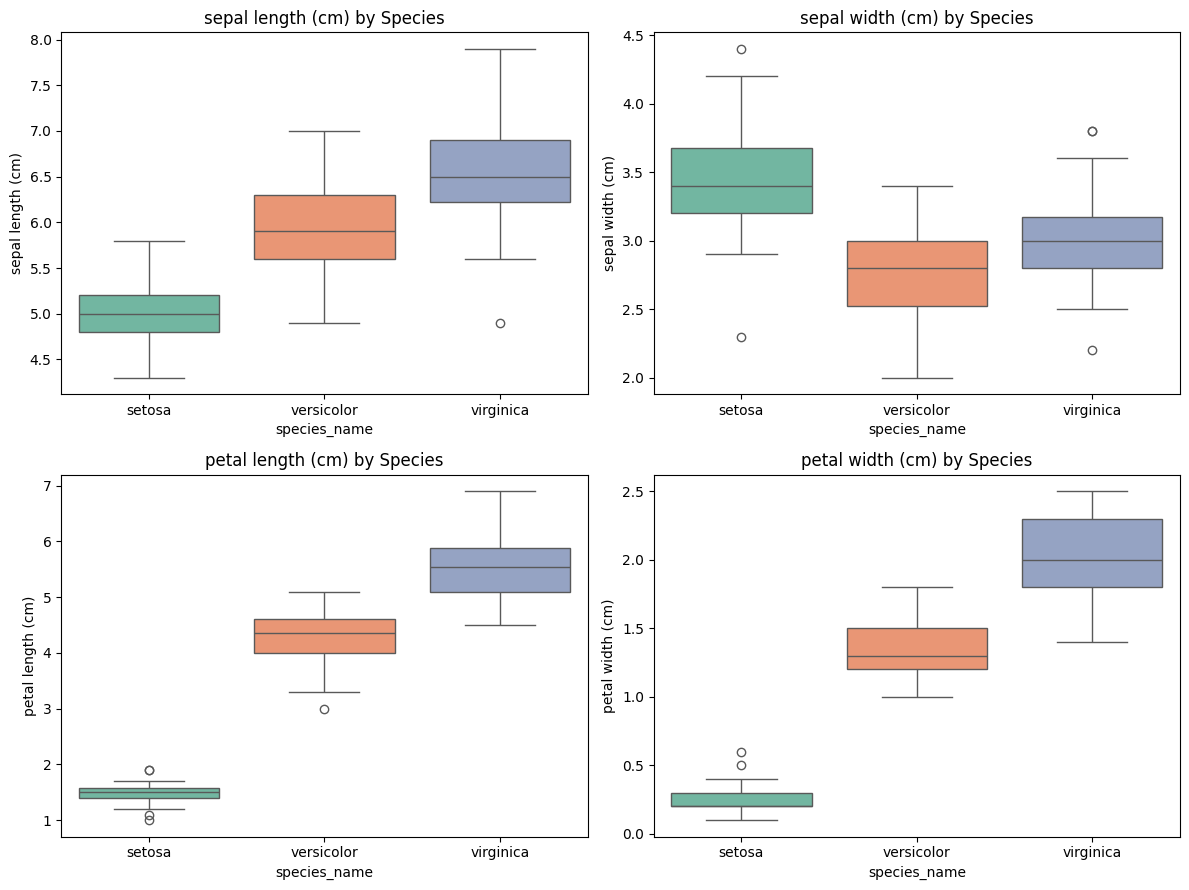

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(data=df, x='species_name', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()

## 4. Feature Selection Discussion

Looking at the pairplot and box plots above:

- **Petal length** and **petal width** show the clearest separation between the three species — Setosa is completely distinct, and Versicolor/Virginica have only minor overlap.
- **Sepal length** and **sepal width** are noisier, with more overlap between Versicolor and Virginica.
- This means petal measurements are the most discriminative features for this classification task, and a model relying mainly on them should already perform very well.

*(Feel free to rewrite this in your own words once you've looked at your own plots — this is meant to be your own observation, not a fixed answer.)*

## 5. Train/Test Split

Using an 80/20 split, stratified by species to keep class proportions balanced.

In [ ]:
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120, 4)
Test shape: (30, 4)


## 6. Train Multiple Classifiers

Training three different models: Logistic Regression, K-Nearest Neighbors, and Decision Tree.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
KNN trained.
Decision Tree trained.


## 7. Evaluate Each Model

For each model, compute accuracy, confusion matrix, and classification report (precision, recall, F1).

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

results = {}

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"===== {name} =====")
    print(f"Accuracy: {acc:.4f}\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("\nClassification Report:")
    print(classification_report(y_test, preds, target_names=iris.target_names))
    print("\n")

===== Logistic Regression =====
Accuracy: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



===== KNN =====
Accuracy: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00      

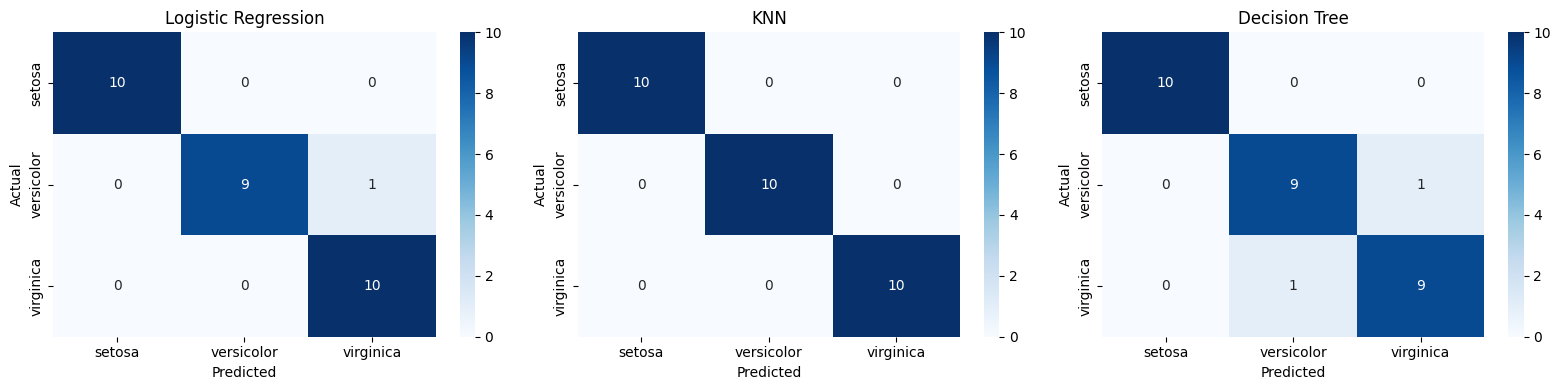

In [ ]:
# Visualise confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. Best-Performing Model

Compare accuracy scores across all models.

In [ ]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)
results_df

,Model,Accuracy
1,KNN,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333


### Conclusion

Run the cell above and note which model comes out on top for your split. On the Iris dataset it's common for all three models to score very highly (often 95–100% accuracy) since the classes are well-separated by petal measurements — but pick whichever model actually has the highest accuracy/F1 in your results table, and justify it using the confusion matrix (e.g. fewest misclassifications) and classification report.

**Example justification template:**
> "[Model name] achieved the highest accuracy of [X]%, with [Y] misclassifications in the confusion matrix, mostly between Versicolor and Virginica — the two species with overlapping petal measurements. It also had the most balanced precision and recall across all three classes."